In [81]:
import os
import shutil
import zipfile
import pandas as pd
import sqlalchemy as sal
import plotly.express as px

# Project path
project_path = r"D:\Project ALl\netflix_title_project"

# Subfolders
folders = [
    "data/raw",
    "data/extracted",
    "data/processed",
    "extract",
    "load",
    "analysis"
]

# Create folders
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project folders created successfully")


Project folders created successfully


In [76]:
# Assuming ZIP file is already in data/raw
zip_file = os.path.join(project_path, "data/raw/archive (1).zip")
extract_path = os.path.join(project_path, "data/extracted")

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully")

ZIP extracted successfully


In [77]:
# Read CSV (assume single CSV in extracted folder)
csv_files = [f for f in os.listdir(extract_path) if f.endswith(".csv")]
csv_path = os.path.join(extract_path, csv_files[0])

df = pd.read_csv(csv_path)

# Simple cleaning
df = df.drop_duplicates()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Save cleaned CSV
processed_csv = os.path.join(project_path, "data/processed/netflix_titles_cleaned.csv")
df.to_csv(processed_csv, index=False)
print("CSV cleaned and saved to processed folder")

CSV cleaned and saved to processed folder


In [63]:
import pandas as pd
import os

project_path = r"D:\Project ALl\netflix_title_project"
extract_path = os.path.join(project_path, "data", "extracted")

# Detect CSV file in extracted folder
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]
csv_path = os.path.join(extract_path, csv_files[0])

# Load CSV into Pandas
df = pd.read_csv(csv_path)

# Show first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [78]:
# SQL Server connection
server = "DESKTOP-CJ2TM4F"
database = "master"
driver = "ODBC Driver 17 for SQL Server"

engine = sal.create_engine(f"mssql+pyodbc://@{server}/{database}?driver={driver}")

with engine.connect() as conn:
    df.to_sql("Netflix_Raw", con=conn, index=False, if_exists="replace")
    print("Data loaded to SQL Server successfully")

Data loaded to SQL Server successfully


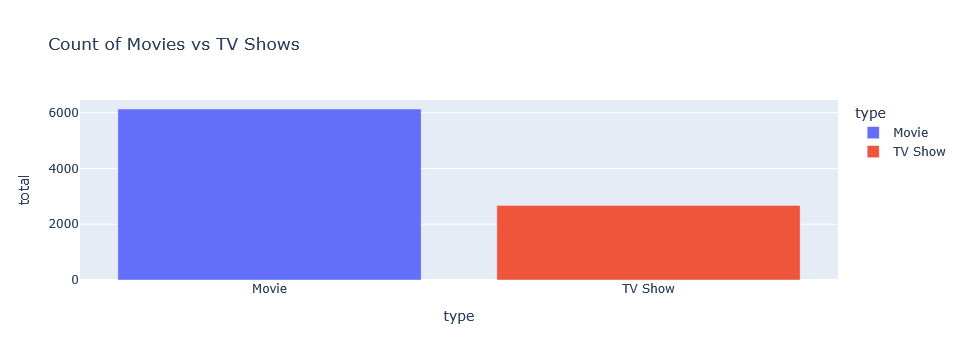

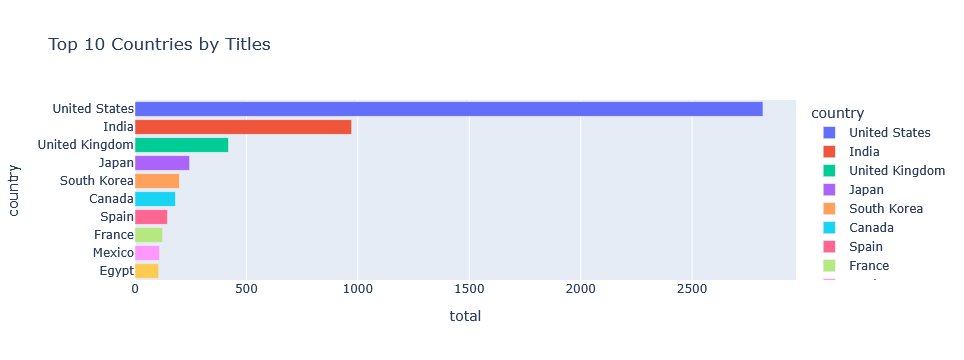

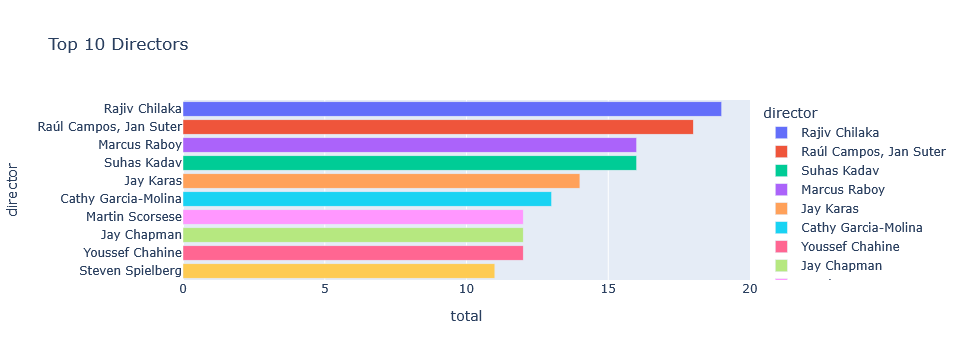

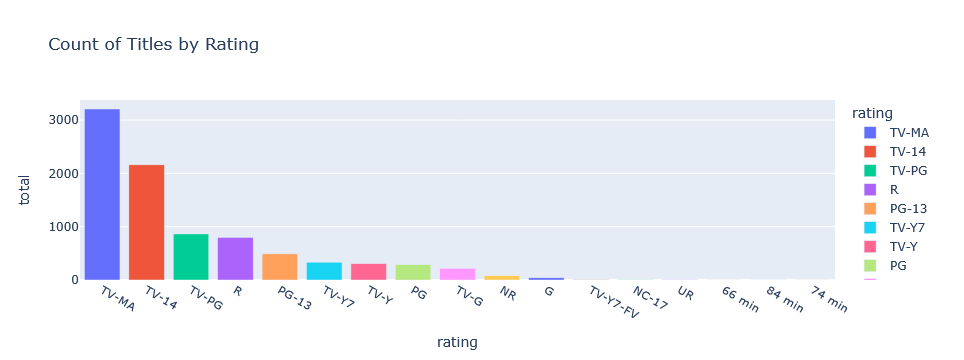

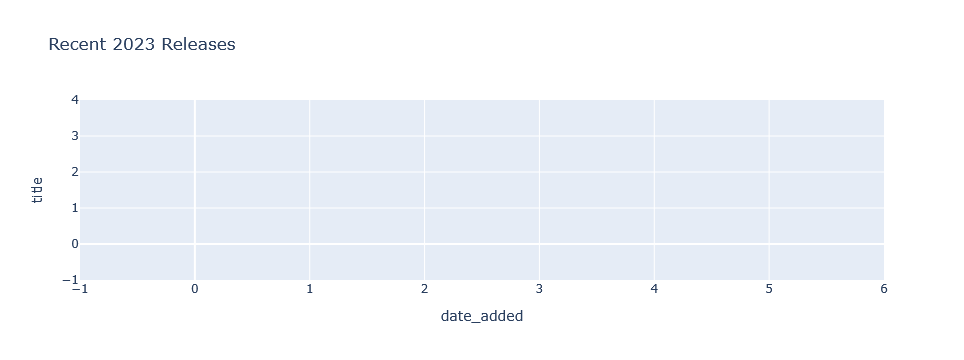

In [83]:
fig1 = px.bar(df_type, x="type", y="total", color="type", title="Count of Movies vs TV Shows")
fig1.show()

df_country = df.groupby("country").size().reset_index(name="total").sort_values(by="total", ascending=False).head(10)
fig2 = px.bar(df_country, x="total", y="country", orientation='h', color="country", title="Top 10 Countries by Titles")
fig2.update_layout(yaxis={'categoryorder':'total ascending'})
fig2.show()

df_director = df.groupby("director").size().reset_index(name="total").sort_values(by="total", ascending=False).head(10)
fig3 = px.bar(df_director, x="total", y="director", orientation='h', color="director", title="Top 10 Directors")
fig3.update_layout(yaxis={'categoryorder':'total ascending'})
fig3.show()

df_rating = df.groupby("rating").size().reset_index(name="total").sort_values(by="total", ascending=False)
fig4 = px.bar(df_rating, x="rating", y="total", color="rating", title="Count of Titles by Rating")
fig4.show()

df_recent = df[df['date_added'].dt.year == 2023].sort_values(by="date_added", ascending=False).head(10)
fig5 = px.bar(df_recent, x="date_added", y="title", orientation='h', color="title", title="Recent 2023 Releases")
fig5.update_layout(yaxis={'categoryorder':'total ascending'})
fig5.show()
